# City Lifestyle Clustering Analysis

## Project Overview
This project performs **Hierarchical Clustering** on a city lifestyle dataset to identify patterns and groups based on lifestyle-related features.

### Objectives
- Perform data cleaning and preprocessing
- Conduct Exploratory Data Analysis (EDA)
- Apply feature scaling
- Build a dendrogram for optimal cluster selection
- Apply Hierarchical Clustering
- Analyze and visualize cluster patterns


## Machine Learning Workflow

```text
Import Dataset
      ↓
Data Cleaning
      ↓
Exploratory Data Analysis (EDA)
      ↓
Feature Selection
      ↓
Feature Scaling
      ↓
Hierarchical Clustering
      ↓
Cluster Visualization & Insights
```


In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [2]:
df = pd.read_csv("city_lifestyle_dataset.csv")
df

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [4]:
df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


In [5]:
df.describe(include=object)

,city_name,country
count,300,300
unique,300,6
top,Townshire,Asia
freq,1,80


## Data Cleaning

In [6]:
df.isnull().sum()

df.drop_duplicates(inplace=True)

## Exploratory Data Analysis (EDA)

In [7]:
freq = df["country"].value_counts()
df["country_freq"] = df["country"].map(freq)

In [8]:
df.drop(columns=["city_name","country"],inplace=True)
df.head()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,country_freq
0,2775,3850,86.4,1310,43,52.0,8.5,23.8,60
1,3861,3700,78.1,1330,42,62.8,8.1,33.1,60
2,2562,4310,80.1,1330,39,73.2,8.5,40.2,60
3,3192,3970,81.2,1480,60,49.2,8.5,43.6,60
4,3496,4320,100.0,1510,64,93.7,8.5,42.5,60


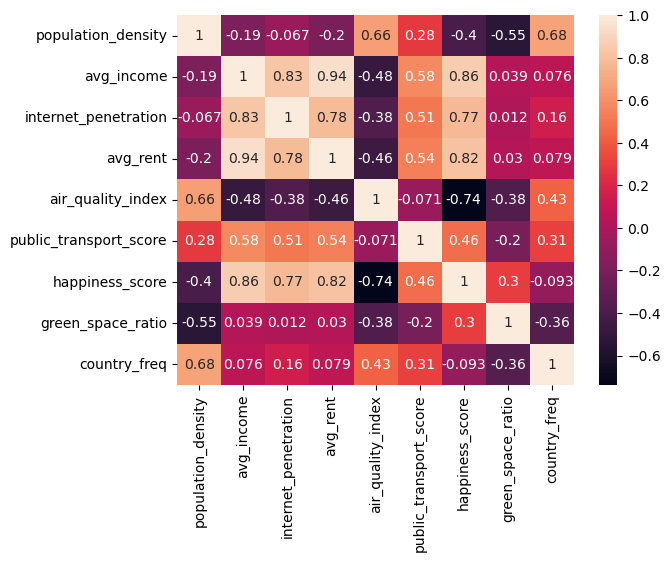

In [9]:
sns.heatmap(df.corr(), annot=True)
plt.show()

<Axes: >

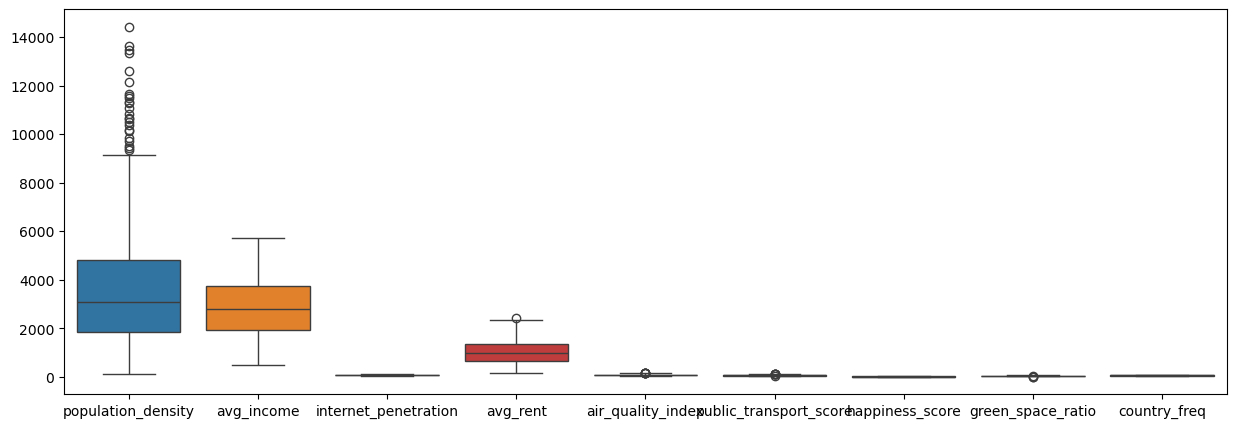

In [10]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df)

# Feature Selection

In [11]:
n = df.copy()
n.tail()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,country_freq
295,1004,4620,100.0,1500,40,64.2,8.5,50.2,35
296,1652,4500,100.0,1650,44,49.3,8.5,37.4,35
297,836,3910,98.7,1340,40,55.7,8.5,38.6,35
298,758,3490,91.2,1390,36,54.1,8.5,44.6,35
299,1235,4330,86.4,1150,41,75.3,8.5,39.9,35


## Feature Scaling

In [12]:
sc = StandardScaler()

n = sc.fit_transform(n)
n

array([[-0.39288239,  0.85293015,  0.71203271, ...,  1.10275857,
        -1.08228661,  0.27945399],
       [-0.0281581 ,  0.72784262,  0.2233982 , ...,  0.86509508,
        -0.09485049,  0.27945399],
       [-0.46441671,  1.2365319 ,  0.34114145, ...,  1.10275857,
         0.65899858,  0.27945399],
       ...,
       [-1.0440798 ,  0.90296516,  1.43615372, ...,  1.10275857,
         0.4891171 , -1.16599767],
       [-1.07027547,  0.55272009,  0.99461652, ...,  1.10275857,
         1.12617266, -1.16599767],
       [-0.91007889,  1.25321024,  0.71203271, ...,  1.10275857,
         0.6271458 , -1.16599767]])

# Create Dendrogram

In [13]:
lk = hierarchy.linkage(n,method="complete")

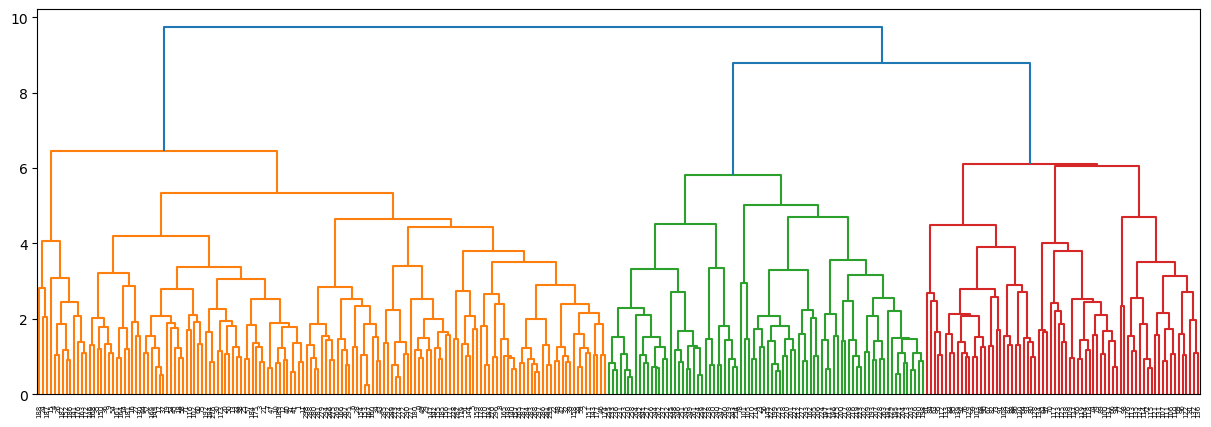

In [14]:
plt.figure(figsize=(15,5))
dendogram = hierarchy.dendrogram(lk)

# Model Building - Apply Hierarchical Clustering

In [15]:
hc = AgglomerativeClustering(n_clusters=3)

In [16]:
labels = hc.fit_predict(n)
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

# Add Cluster Labels

In [17]:
df["Cluster_3"] = labels
df["Cluster_3"]

0      0
1      0
2      0
3      0
4      0
      ..
295    0
296    0
297    0
298    0
299    0
Name: Cluster_3, Length: 300, dtype: int64

In [18]:
y = df["Cluster_3"]

# Cluster Analysis

In [19]:
df.groupby("Cluster_3").mean()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,country_freq
Cluster_3,,,,,,,,,
0,2432.167785,3743.020134,85.322819,1341.275168,55.174497,60.468456,8.060403,37.076510,52.416107
1,3018.481013,1434.050633,55.067089,498.860759,78.126582,42.940506,4.994937,35.427848,37.721519
2,8091.666667,2460.555556,72.613889,855.138889,96.958333,59.904167,5.522222,26.038889,80.000000


# Supervised Classification Model

In [20]:
X_train,X_test,y_train,y_test = train_test_split(n,y,test_size=0.25,random_state=0)

In [21]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [22]:
y_pred = lr.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 1, 2,
       2, 2, 1, 0, 0, 0, 1, 0, 2, 2, 0, 2, 1, 0, 0, 0, 0, 0, 1, 2, 2, 0,
       0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2, 0, 0, 1,
       1, 2, 0, 0, 0, 1, 0, 0, 0])

In [23]:
y_test

208    1
188    0
12     0
221    1
239    1
      ..
156    0
228    1
273    0
27     0
144    0
Name: Cluster_3, Length: 75, dtype: int64

In [24]:
confusion_matrix(y_test,y_pred)

array([[35,  0,  0],
       [ 2, 19,  0],
       [ 0,  0, 19]])

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        35
           1       1.00      0.90      0.95        21
           2       1.00      1.00      1.00        19

    accuracy                           0.97        75
   macro avg       0.98      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



# Conclusion

This project successfully applied **Hierarchical Clustering** to identify meaningful groups within the city lifestyle dataset.

### Key Takeaways
- Data preprocessing and scaling improved clustering performance
- EDA helped understand feature relationships and distributions
- Dendrogram analysis assisted in selecting the optimal number of clusters
- Hierarchical clustering revealed distinct lifestyle-based groups

The analysis can support decision-making in areas such as customer segmentation, urban planning, and lifestyle trend analysis.
